<a href="https://colab.research.google.com/github/Shah-Shawon/Deep-Learing-Assignments/blob/main/assignment2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
!pip install umap-learn mtcnn opencv-python

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.9/1.9 MB 28.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 47.1 MB/s eta 0:00:00


In [3]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import umap.umap_ as umap

from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.datasets import cifar10

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from mtcnn import MTCNN

In [4]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS = 5

np.random.seed(42)
tf.random.set_seed(42)

In [5]:
def preprocess_images(images):
    resized = np.array([cv2.resize(img, (IMG_SIZE, IMG_SIZE)) for img in images])
    resized = resized.astype("float32")
    resized = preprocess_input(resized)
    return resized
def build_feature_extractor():
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )
    x = GlobalAveragePooling2D()(base_model.output)
    model = Model(inputs=base_model.input, outputs=x)
    return model
def build_finetune_model(num_classes):
    base_model = MobileNetV2(
        weights='imagenet',
        include_top=False,
        input_shape=(IMG_SIZE, IMG_SIZE, 3)
    )

    x = GlobalAveragePooling2D()(base_model.output)
    x = Dropout(0.3)(x)
    outputs = Dense(num_classes, activation='softmax')(x)

    model = Model(inputs=base_model.input, outputs=outputs)
    return model, base_model
def extract_features(model, images):
    return model.predict(images, batch_size=BATCH_SIZE, verbose=1)
def plot_embedding(embedding, labels, title, class_names=None):
    plt.figure(figsize=(8, 6))
    unique_labels = np.unique(labels)

    for label in unique_labels:
        idx = labels == label
        label_name = class_names[label] if class_names is not None else str(label)
        plt.scatter(embedding[idx, 0], embedding[idx, 1], label=label_name, alpha=0.7)

    plt.title(title)
    plt.legend()
    plt.grid(True)
    plt.show()
def reduce_and_plot(features, labels, stage_name, class_names=None):
    n_samples = features.shape[0]
    print(f"{stage_name}: samples = {n_samples}, feature_dim = {features.shape[1]}")

    if n_samples < 2:
        print("Not enough samples for 2D reduction.")
        return

    # PCA
    pca = PCA(n_components=2)
    pca_result = pca.fit_transform(features)
    plot_embedding(pca_result, labels, f"{stage_name} - PCA", class_names)

    # t-SNE
    if n_samples < 3:
        print("Not enough samples for t-SNE.")
    else:
        safe_perplexity = min(30, n_samples - 1)
        tsne = TSNE(n_components=2, random_state=42, perplexity=safe_perplexity)
        tsne_result = tsne.fit_transform(features)
        plot_embedding(tsne_result, labels, f"{stage_name} - t-SNE", class_names)

    # UMAP
    if n_samples < 2:
        print("Not enough samples for UMAP.")
    else:
        umap_model = umap.UMAP(n_components=2, random_state=42)
        umap_result = umap_model.fit_transform(features)
        plot_embedding(umap_result, labels, f"{stage_name} - UMAP", class_names)
def show_samples(images, labels, class_names, title="Samples", n=9):
    plt.figure(figsize=(8, 8))
    for i in range(min(n, len(images))):
        plt.subplot(3, 3, i+1)
        plt.imshow(images[i].astype("uint8"))
        plt.title(class_names[labels[i]])
        plt.axis("off")
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()

In [ ]:
detector = MTCNN()

def load_face_dataset(dataset_path, max_images_per_class=50):
    images = []
    labels = []
    class_names = []
    current_label = 0

    for person_name in sorted(os.listdir(dataset_path)):
        person_path = os.path.join(dataset_path, person_name)
        if not os.path.isdir(person_path):
            continue

        class_names.append(person_name)
        count = 0

        for file_name in os.listdir(person_path):
            if count >= max_images_per_class:
                break

            file_path = os.path.join(person_path, file_name)
            img = cv2.imread(file_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            detections = detector.detect_faces(img)

            if len(detections) > 0:
                x, y, w, h = detections[0]['box']
                x, y = max(0, x), max(0, y)
                face = img[y:y+h, x:x+w]

                if face.size == 0:
                    continue

                face = cv2.resize(face, (IMG_SIZE, IMG_SIZE))
                images.append(face)
                labels.append(current_label)
                count += 1

        current_label += 1

    return np.array(images), np.array(labels), class_names

(16, 224, 224, 3)
['hasan', 'onlline face']


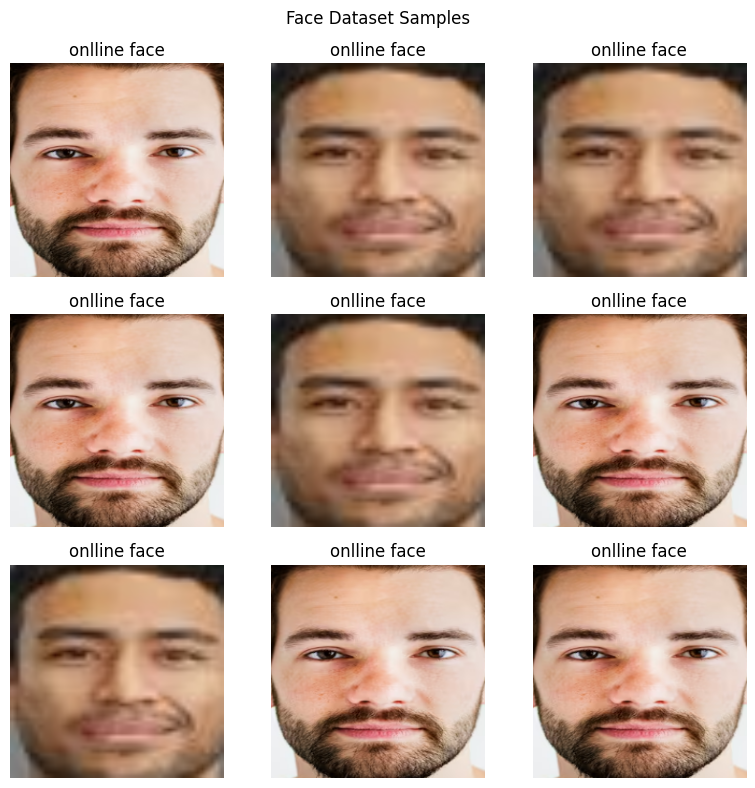

In [ ]:
face_dataset_path = "/content/drive/MyDrive/DL/Assignment2/face_dataset"   # change if needed
face_images, face_labels, face_class_names = load_face_dataset(face_dataset_path)

print(face_images.shape)
print(face_class_names)

show_samples(face_images, face_labels, face_class_names, title="Face Dataset Samples")

In [ ]:
X_face_train, X_face_val, y_face_train, y_face_val = train_test_split(
    face_images, face_labels, test_size=0.2, random_state=42, stratify=face_labels
)

X_face_train_pre = preprocess_images(X_face_train)
X_face_val_pre = preprocess_images(X_face_val)

y_face_train_cat = to_categorical(y_face_train, num_classes=len(face_class_names))
y_face_val_cat = to_categorical(y_face_val, num_classes=len(face_class_names))

1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step
Face Recognition Before Fine-Tuning: samples = 16, feature_dim = 1280


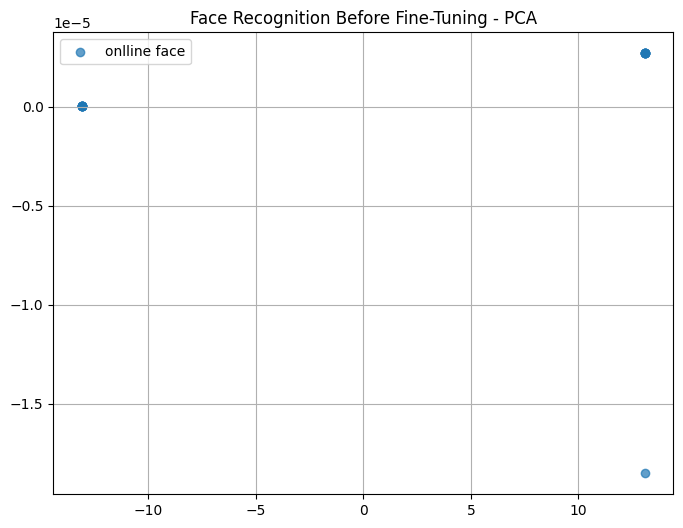

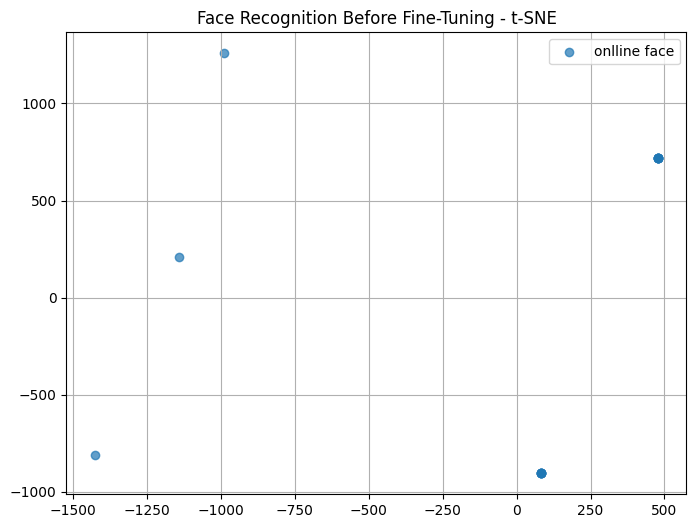

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


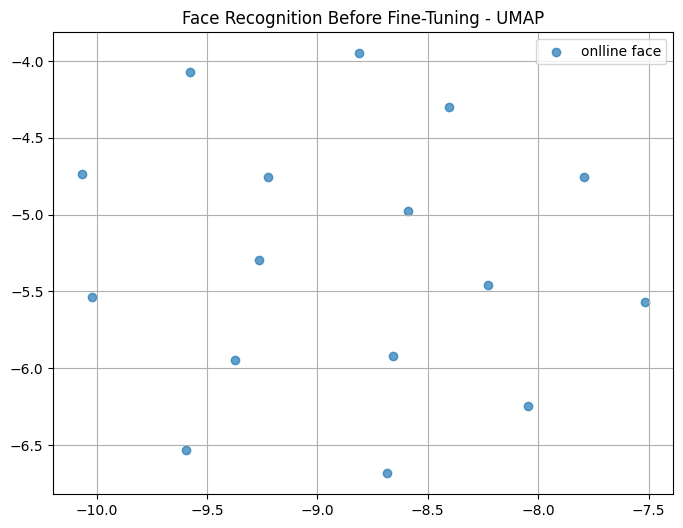

In [ ]:
X_face_all_pre = preprocess_images(face_images)

face_feature_model_before = build_feature_extractor()
face_features_before = extract_features(face_feature_model_before, X_face_all_pre)

reduce_and_plot(
    face_features_before,
    face_labels,
    "Face Recognition Before Fine-Tuning",
    face_class_names
)

In [ ]:
face_model, face_base_model = build_finetune_model(num_classes=len(face_class_names))

for layer in face_base_model.layers[:-20]:
    layer.trainable = False

for layer in face_base_model.layers[-20:]:
    layer.trainable = True

face_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_face = face_model.fit(
    X_face_train_pre, y_face_train_cat,
    validation_data=(X_face_val_pre, y_face_val_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 21s 21s/step - accuracy: 0.6667 - loss: 0.5714 - val_accuracy: 1.0000 - val_loss: 0.2082
Epoch 2/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 799ms/step - accuracy: 1.0000 - loss: 0.1833 - val_accuracy: 1.0000 - val_loss: 0.2050
Epoch 3/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0883 - val_accuracy: 1.0000 - val_loss: 0.2020
Epoch 4/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 735ms/step - accuracy: 1.0000 - loss: 0.0521 - val_accuracy: 1.0000 - val_loss: 0.2008
Epoch 5/5
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step - accuracy: 1.0000 - loss: 0.0198 - val_accuracy: 1.0000 - val_loss: 0.2005


1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step
Face Recognition After Fine-Tuning: samples = 4, feature_dim = 1280


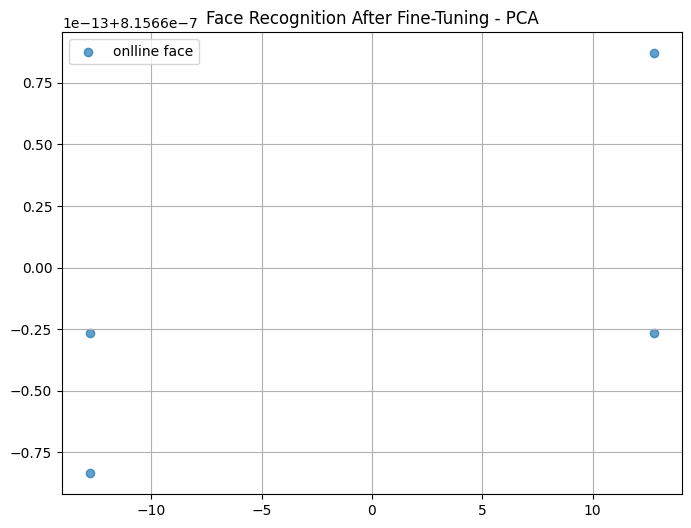

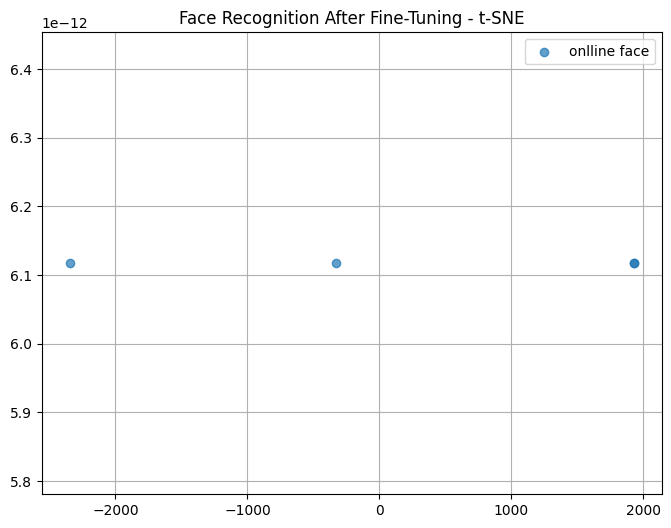

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


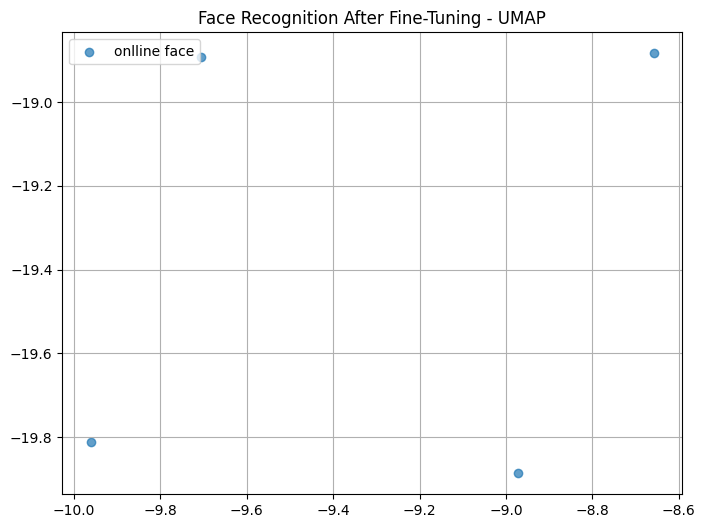

In [ ]:
face_feature_model_after = Model(
    inputs=face_model.input,
    outputs=face_model.layers[-3].output
)

face_features_after = extract_features(face_feature_model_after, X_face_val_pre)

reduce_and_plot(
    face_features_after,
    y_face_val,
    "Face Recognition After Fine-Tuning",
    face_class_names
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 883ms/step
My Face Test Before Fine-Tuning: samples = 16, feature_dim = 1280


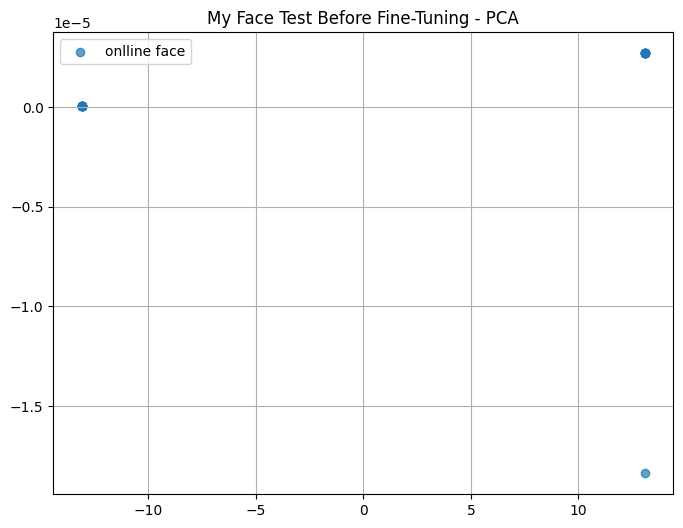

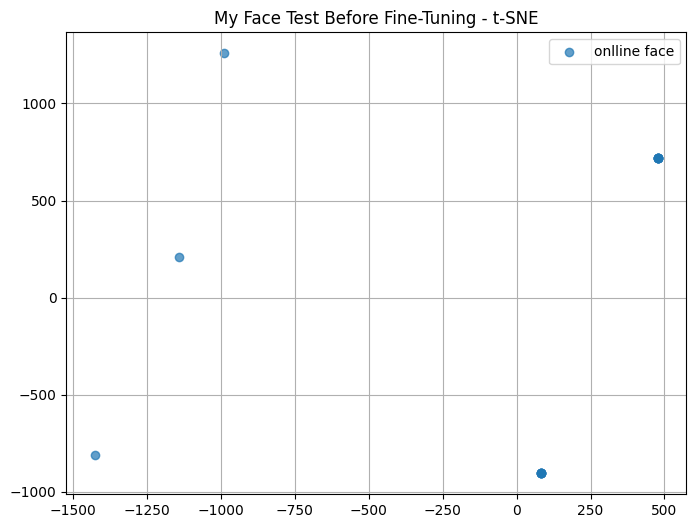

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


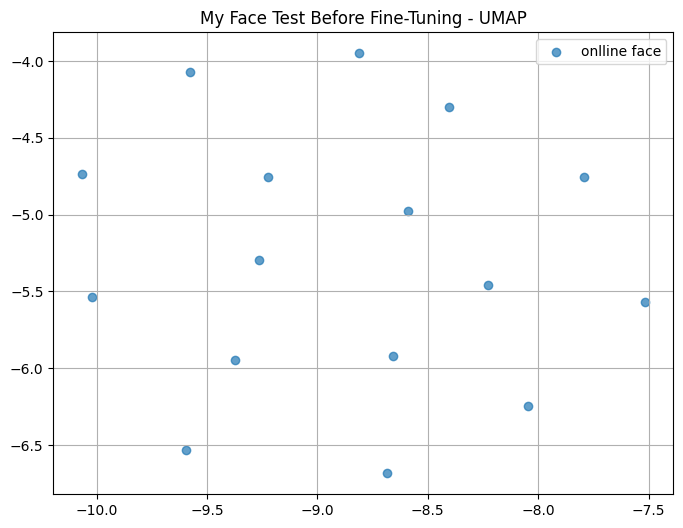

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
My Face Test After Fine-Tuning: samples = 16, feature_dim = 1280


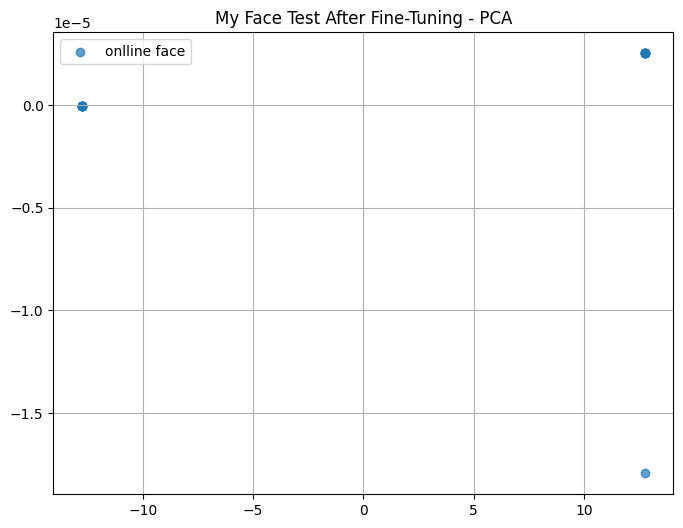

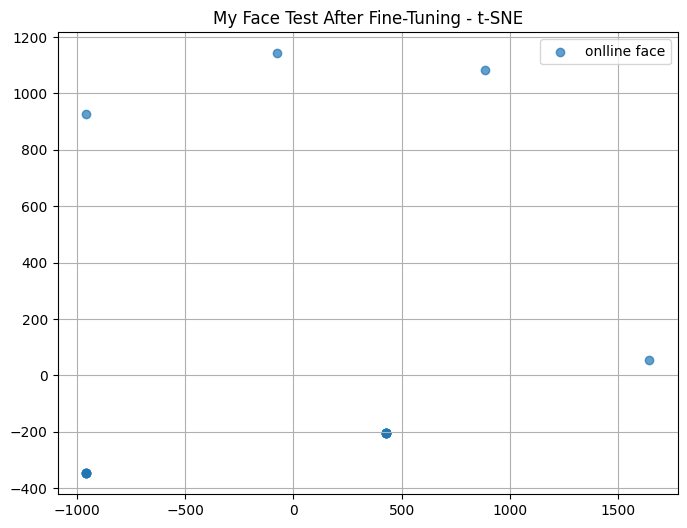

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


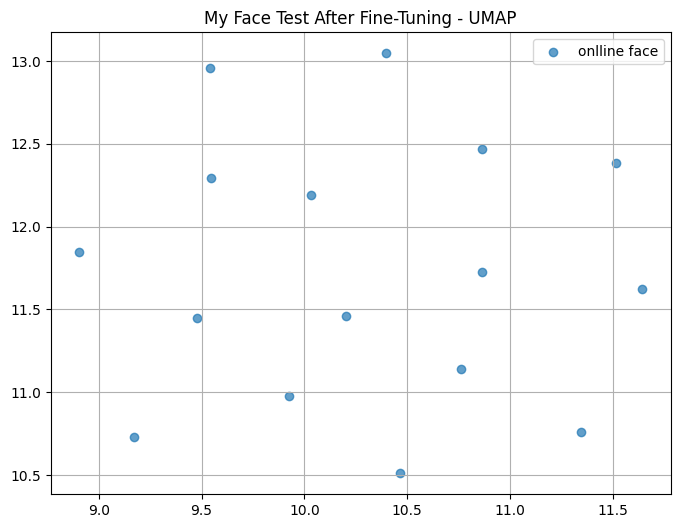

In [ ]:
my_face_test_path = "/content/drive/MyDrive/DL/Assignment2/face_dataset"
my_face_images, my_face_labels, my_face_names = load_face_dataset(my_face_test_path)

X_my_face_pre = preprocess_images(my_face_images)

my_face_features_before = extract_features(face_feature_model_before, X_my_face_pre)
reduce_and_plot(
    my_face_features_before,
    my_face_labels,
    "My Face Test Before Fine-Tuning",
    my_face_names
)

my_face_features_after = extract_features(face_feature_model_after, X_my_face_pre)
reduce_and_plot(
    my_face_features_after,
    my_face_labels,
    "My Face Test After Fine-Tuning",
    my_face_names
)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step
(50000, 32, 32, 3) (10000, 32, 32, 3)


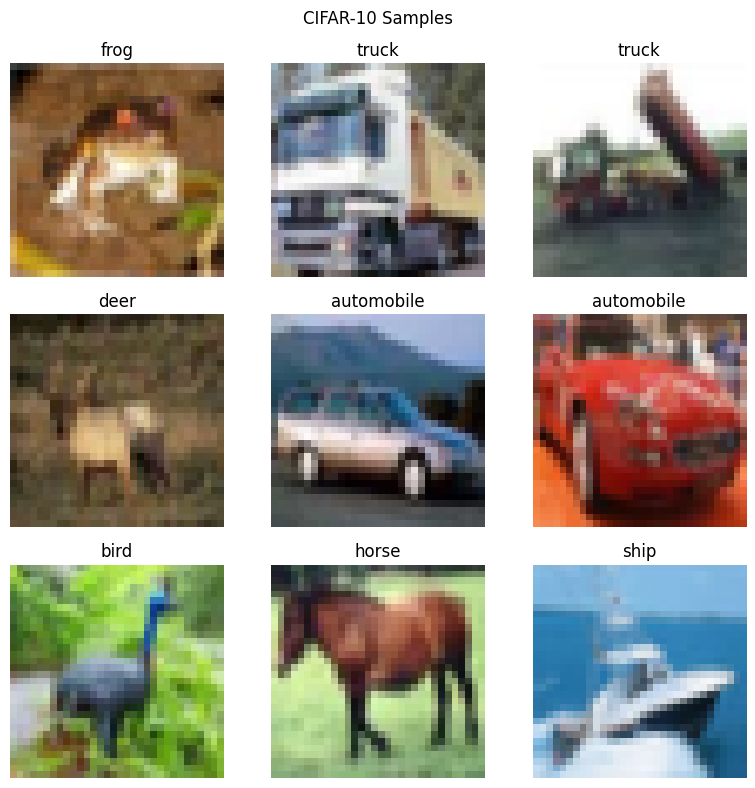

In [ ]:
(X_cifar_train, y_cifar_train), (X_cifar_test, y_cifar_test) = cifar10.load_data()

y_cifar_train = y_cifar_train.flatten()
y_cifar_test = y_cifar_test.flatten()

cifar_class_names = [
    "airplane", "automobile", "bird", "cat", "deer",
    "dog", "frog", "horse", "ship", "truck"
]

print(X_cifar_train.shape, X_cifar_test.shape)
show_samples(X_cifar_train, y_cifar_train, cifar_class_names, title="CIFAR-10 Samples")

In [ ]:
subset_train = 5000
subset_test = 1000

X_cifar_train = X_cifar_train[:subset_train]
y_cifar_train = y_cifar_train[:subset_train]

X_cifar_test = X_cifar_test[:subset_test]
y_cifar_test = y_cifar_test[:subset_test]

In [ ]:
X_cifar_train_pre = preprocess_images(X_cifar_train)
X_cifar_test_pre = preprocess_images(X_cifar_test)

y_cifar_train_cat = to_categorical(y_cifar_train, num_classes=10)
y_cifar_test_cat = to_categorical(y_cifar_test, num_classes=10)

32/32 ━━━━━━━━━━━━━━━━━━━━ 53s 1s/step
CIFAR-10 Before Fine-Tuning: samples = 1000, feature_dim = 1280


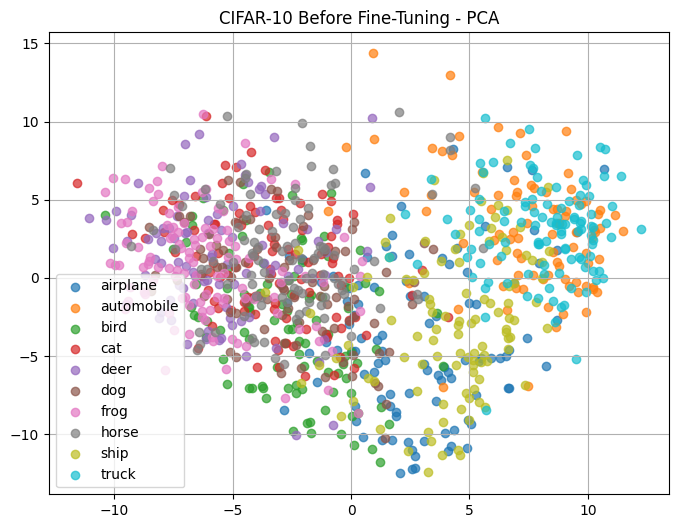

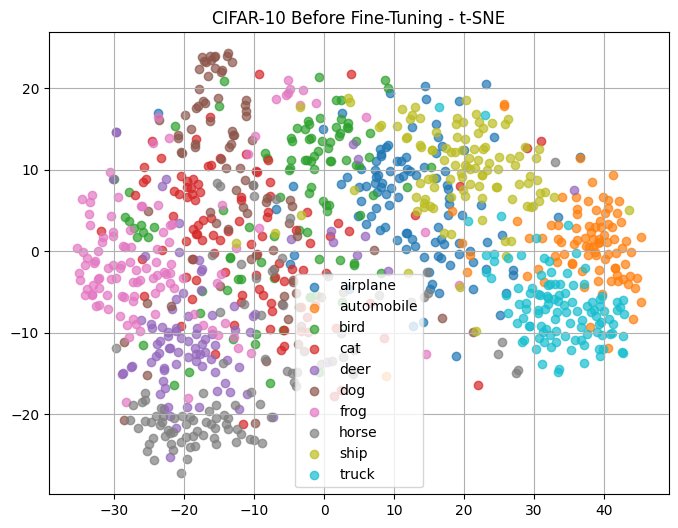

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


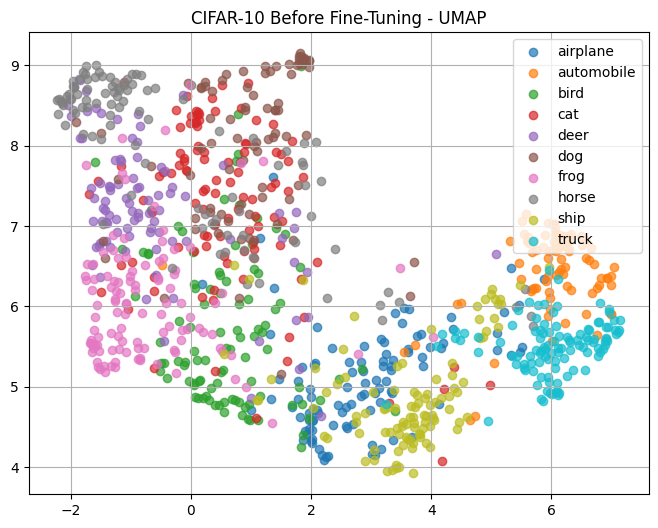

In [ ]:
cifar_feature_model_before = build_feature_extractor()
cifar_features_before = extract_features(cifar_feature_model_before, X_cifar_test_pre)

reduce_and_plot(
    cifar_features_before,
    y_cifar_test,
    "CIFAR-10 Before Fine-Tuning",
    cifar_class_names
)

In [ ]:
cifar_model, cifar_base_model = build_finetune_model(num_classes=10)

for layer in cifar_base_model.layers[:-20]:
    layer.trainable = False

for layer in cifar_base_model.layers[-20:]:
    layer.trainable = True

cifar_model.compile(
    optimizer=Adam(learning_rate=1e-4),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_cifar = cifar_model.fit(
    X_cifar_train_pre, y_cifar_train_cat,
    validation_data=(X_cifar_test_pre, y_cifar_test_cat),
    epochs=EPOCHS,
    batch_size=BATCH_SIZE
)

Epoch 1/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 312s 2s/step - accuracy: 0.6728 - loss: 0.9801 - val_accuracy: 0.7330 - val_loss: 0.7896
Epoch 2/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 282s 2s/step - accuracy: 0.8854 - loss: 0.3703 - val_accuracy: 0.7730 - val_loss: 0.6941
Epoch 3/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 329s 2s/step - accuracy: 0.9472 - loss: 0.1941 - val_accuracy: 0.7810 - val_loss: 0.7124
Epoch 4/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 295s 2s/step - accuracy: 0.9868 - loss: 0.0903 - val_accuracy: 0.7850 - val_loss: 0.7349
Epoch 5/5
157/157 ━━━━━━━━━━━━━━━━━━━━ 324s 2s/step - accuracy: 0.9970 - loss: 0.0465 - val_accuracy: 0.7800 - val_loss: 0.7448


32/32 ━━━━━━━━━━━━━━━━━━━━ 55s 2s/step
CIFAR-10 After Fine-Tuning: samples = 1000, feature_dim = 1280


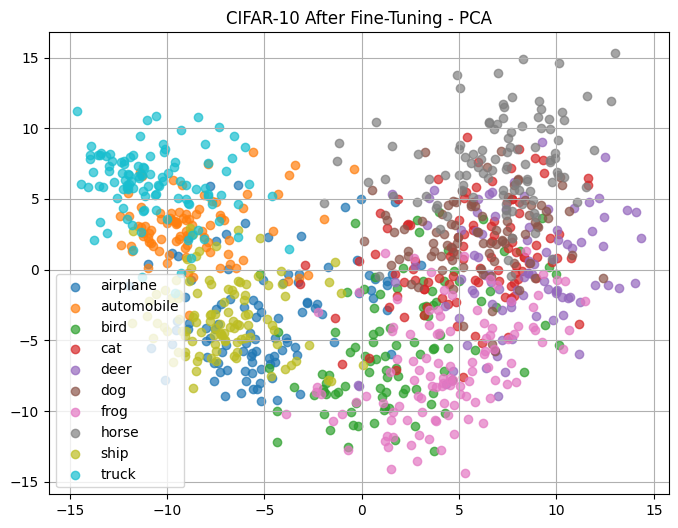

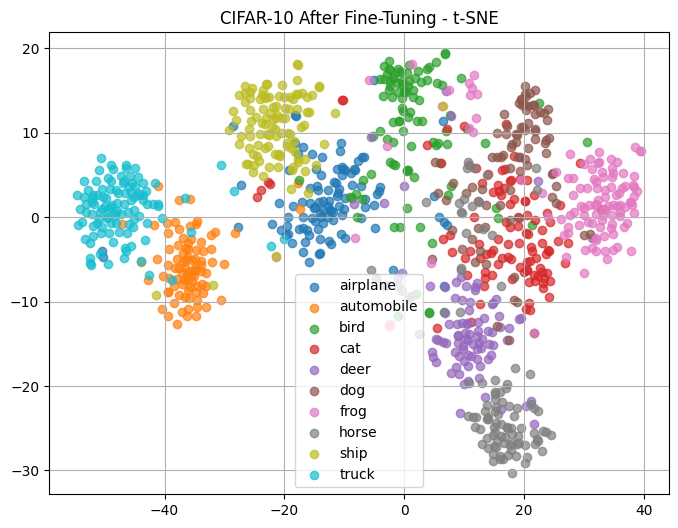

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


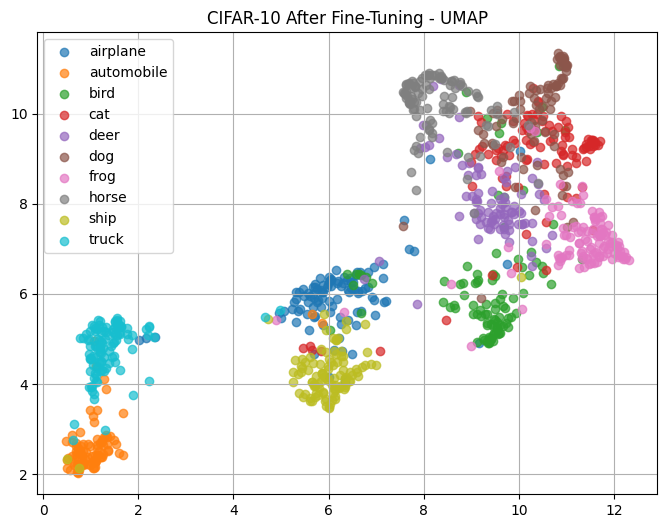

In [ ]:
cifar_feature_model_after = Model(
    inputs=cifar_model.input,
    outputs=cifar_model.layers[-3].output
)

cifar_features_after = extract_features(cifar_feature_model_after, X_cifar_test_pre)

reduce_and_plot(
    cifar_features_after,
    y_cifar_test,
    "CIFAR-10 After Fine-Tuning",
    cifar_class_names
)

In [ ]:
def load_image_folder_dataset(dataset_path, max_images_per_class=50):
    images = []
    labels = []
    class_names = []
    current_label = 0

    for class_name in sorted(os.listdir(dataset_path)):
        class_path = os.path.join(dataset_path, class_name)
        if not os.path.isdir(class_path):
            continue

        class_names.append(class_name)
        count = 0

        for file_name in os.listdir(class_path):
            if count >= max_images_per_class:
                break

            file_path = os.path.join(class_path, file_name)
            img = cv2.imread(file_path)
            if img is None:
                continue

            img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
            img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))

            images.append(img)
            labels.append(current_label)
            count += 1

        current_label += 1

    return np.array(images), np.array(labels), class_names

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step   
My Flower Test Before Fine-Tuning: samples = 5, feature_dim = 1280


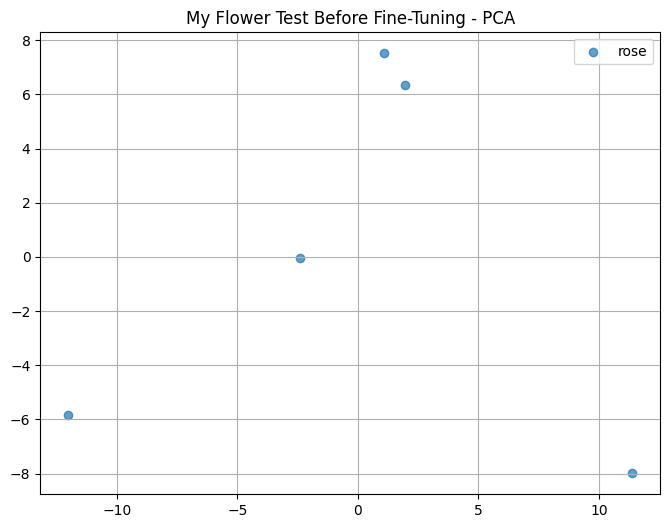

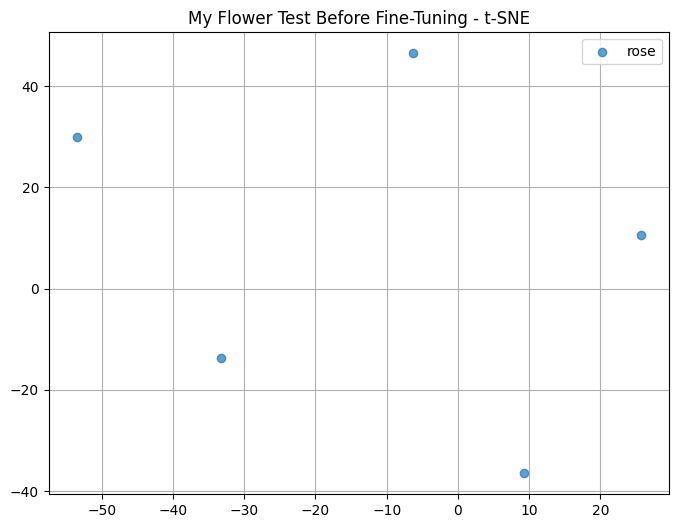

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


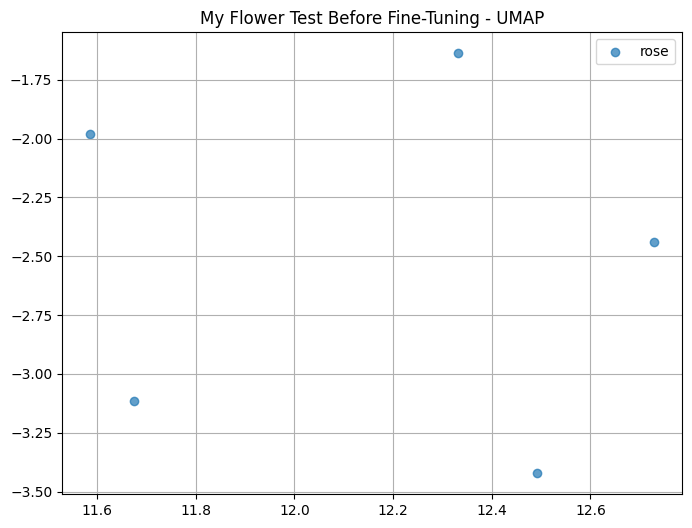

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 869ms/step
My Flower Test After Fine-Tuning: samples = 5, feature_dim = 1280


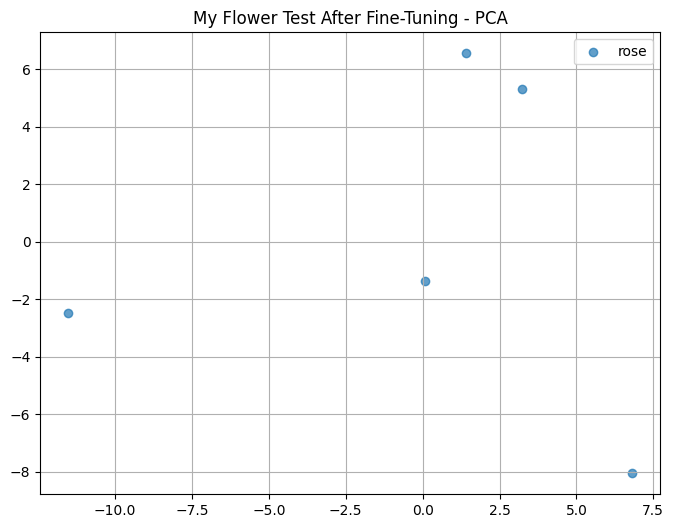

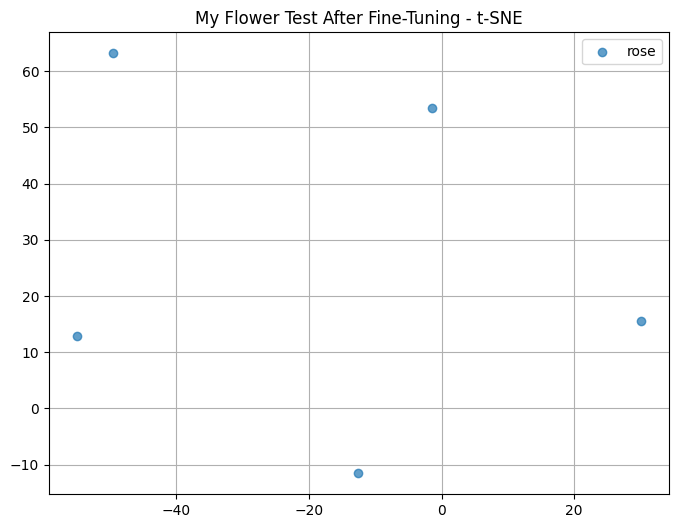

/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(
/usr/local/lib/python3.12/dist-packages/umap/umap_.py:2462: UserWarning: n_neighbors is larger than the dataset size; truncating to X.shape[0] - 1
  warn(


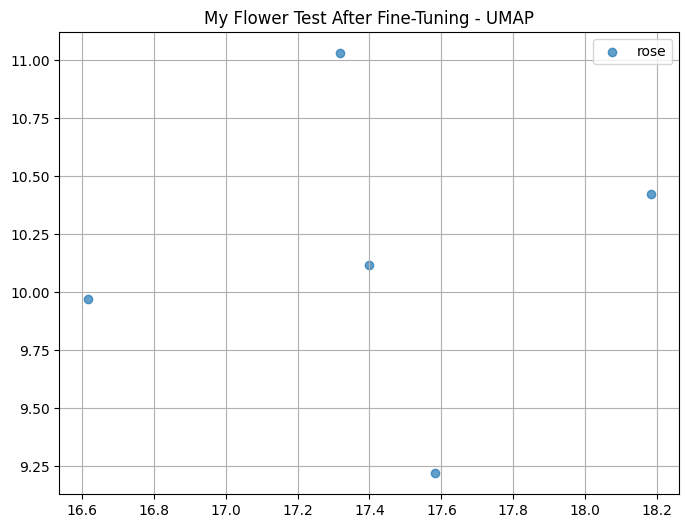

In [ ]:
my_flower_path = "/content/drive/MyDrive/DL/Assignment1/flowers"
my_flower_images, my_flower_labels, my_flower_names = load_image_folder_dataset(my_flower_path)

X_my_flower_pre = preprocess_images(my_flower_images)

my_flower_features_before = extract_features(cifar_feature_model_before, X_my_flower_pre)
reduce_and_plot(
    my_flower_features_before,
    my_flower_labels,
    "My Flower Test Before Fine-Tuning",
    my_flower_names
)

my_flower_features_after = extract_features(cifar_feature_model_after, X_my_flower_pre)
reduce_and_plot(
    my_flower_features_after,
    my_flower_labels,
    "My Flower Test After Fine-Tuning",
    my_flower_names
)